<center>

**<font color = "red">Project: Classification of Medical Images</font>**

---
**<font color = "green">Pneumonia Detection in Chest X-Rays using Transfer Learning</font>**

*13 April 2026*

---

*L.Chen*

*e-mail: longjie.chen@ifj.edu.pl*

---

</center>


# **Project Overview**

**Objective:** To build and train a deep learning model to accurately classify chest X-ray images as either "Normal" or showing signs of "Pneumonia".

**Methodology:** We will use a powerful technique called **Transfer Learning**. Instead of training a neural network from scratch, we will use a pre-trained model, **ResNet50**, which has already learned to recognize complex features from millions of general images. We will adapt this pre-trained model for our specific medical imaging task.

**Procedure:**
1.  **Setup:** Configure the Colab environment and download the dataset from Kaggle.
2.  **Data Preparation:** Load and preprocess the images, setting up a pipeline with data augmentation to improve model robustness.
3.  **Model Building:** Construct the model by adding a custom classifier on top of the frozen ResNet50 base.
4.  **Training:** Compile and train the model on the prepared data.
5.  **Evaluation:** Evaluate the model's performance on unseen test data and analyze the results using a confusion matrix and other metrics.


### **Step 1: Setup and Data Acquisition**
First, we need to set up the Kaggle API to download our dataset directly into this notebook.

**Action Required:**
1.  If you haven't already, go to your Kaggle account page, scroll to the API section, and click "Create Legacy API Key" to download your `kaggle.json` file.
2.  Run the code cell below. It will prompt you to upload the `kaggle.json` file you just downloaded.


In [1]:
# Install Kaggle library and upload credentials
!pip install -q kaggle

from google.colab import files

print("Please upload your kaggle.json file")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\nKaggle API configured successfully!")


Please upload your kaggle.json file


Saving kaggle.json to kaggle.json

Kaggle API configured successfully!


Download and Unzip the Dataset

Now that the API is configured, we can download and unzip the dataset. You may need to first accept the rules of the dataset on the Kaggle website: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia).


In [2]:
# Download and unzip the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q --unzip

print("Dataset downloaded and unzipped.")
!ls chest_xray # Verify the directory structure


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Dataset downloaded and unzipped.
chest_xray  __MACOSX  test  train  val


### **Step 2: Configuration and Data Preparation**
With the data in place, we will import all necessary libraries and define the key parameters for our experiment, such as image size and batch size.

In [11]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Configuration

BASE_DATA_PATH = '/content/chest_xray/'
TRAIN_DIR = BASE_DATA_PATH + 'train'
VALIDATION_DIR = BASE_DATA_PATH + 'val'
TEST_DIR = BASE_DATA_PATH + 'test'

# Define model and training parameters
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 20 # Start with 20, can be decreased/increased if needed
LEARNING_RATE = 0.0001

Next, we set up our data pipelines using `ImageDataGenerator`. For the training data, we will apply **data augmentation** to create more varied examples and prevent overfitting. For the validation and test data, we only rescale the pixel values to ensure a consistent evaluation.

In [12]:
# Data Preparation and Preprocessing
print("Step 1: Preparing Data Generators...")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = validation_test_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = validation_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode='binary'
)

print("Found class indices:", train_generator.class_indices)

Step 1: Preparing Data Generators...
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


### **Step 3: Model Building (Transfer Learning)**
Here, we construct our model. We load the ResNet50 architecture with weights pre-trained on ImageNet, chop off its original classification head, and freeze its layers. Then, we add our own new classifier on top. Only the layers of this new classifier will be trained initially.

In [13]:
# Model Selection and Architecture
print("\nStep 2: Building the Model...")

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))
base_model.trainable = False # Freeze the base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()


Step 2: Building the Model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### **Step 4: Model Training**
Now we configure the model for training by compiling it with an optimizer, loss function, and performance metrics. Then, we begin the training process using the `.fit()` method. Please be patient at this step, as we have set `EPOCH=20` and `LEARNING_RATE=0.0001`

In [14]:
# Compile and Train the Model
print("\nStep 3: Compiling and Training...")

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# Please select GPU
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)



Step 3: Compiling and Training...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 707ms/step - accuracy: 0.7053 - loss: 0.6191 - precision: 0.7414 - recall: 0.9265 - val_accuracy: 0.5000 - val_loss: 0.7424 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 726ms/step - accuracy: 0.7395 - loss: 0.5700 - precision: 0.7438 - recall: 0.9905 - val_accuracy: 0.5000 - val_loss: 0.7805 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 686ms/step - accuracy: 0.7429 - loss: 0.5370 - precision: 0.7436 - recall: 0.9982 - val_accuracy: 0.5000 - val_loss: 0.8229 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 674ms/step - accuracy: 0.7448 - loss: 0.5221 - precision: 0.7456 - recall: 0.9966 - val_accuracy: 0.5000 - val_loss: 0.7213 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 675ms/step - accuracy: 0.7441 - loss: 0.5061 - precision: 0.7473

### **Step 5: Evaluation and Analysis**
With the model trained, we perform a final, unbiased evaluation on the test set. We will calculate the key metrics and visualize the model's performance with a confusion matrix, which shows us exactly what kinds of correct and incorrect predictions it made.


Step 4: Evaluating the Model on the Test Set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - accuracy: 0.7228 - loss: 0.5185 - precision: 0.7123 - recall: 0.9333

Test Accuracy: 72.28%
Test Precision: 71.23%
Test Recall: 93.33%
Test Loss: 0.5185
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 456ms/step


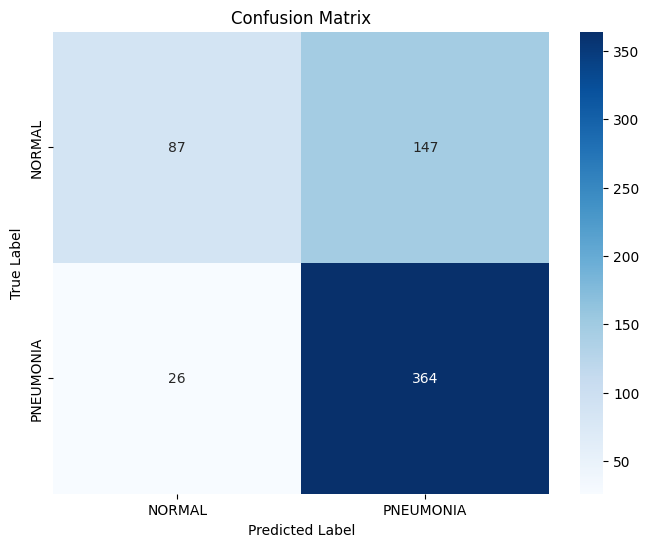


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.77      0.37      0.50       234
   PNEUMONIA       0.71      0.93      0.81       390

    accuracy                           0.72       624
   macro avg       0.74      0.65      0.65       624
weighted avg       0.73      0.72      0.69       624



In [15]:
# Evaluation
print("\nStep 4: Evaluating the Model on the Test Set...")

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Precision: {test_precision*100:.2f}%")
print(f"Test Recall: {test_recall*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

### **Step 6: Visualizing Training History**
Finally, we plot the accuracy and loss curves for both the training and validation sets over each epoch. This is a crucial step to visually inspect for signs of overfitting (where the training performance improves but validation performance gets worse).

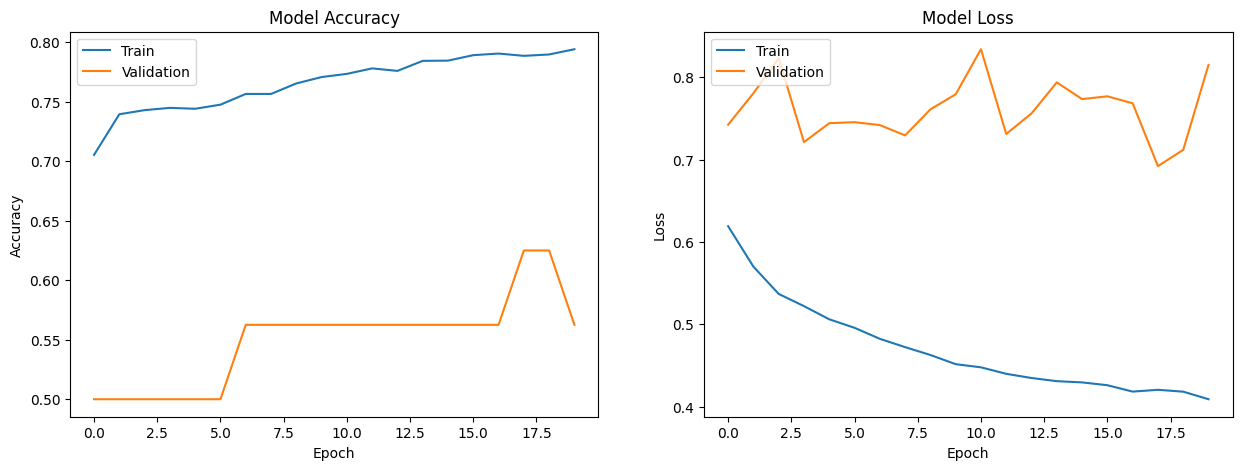

In [16]:
# Plot Training History
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')

    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_history(history)